In [2]:
import torch
import torch.nn.functional as F
import argparse
import numpy as np


torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

from torchvision.utils import save_image
from diffusion import create_diffusion

from diffusers.models import AutoencoderKL
from models import VDT_models
from mask_generator import VideoMaskGenerator
from utils import load_checkpoint
from autoencoder import SequenceAutoencoderKL

In [3]:
parser = argparse.ArgumentParser()
parser.add_argument("--model", type=str, choices=list(VDT_models.keys()), default="VDT-L/2")
parser.add_argument("--vae", type=str, choices=["ema", "mse"], default="ema")
parser.add_argument("--image-size", type=int, default=64)
parser.add_argument("--f", type=str, default=None)
parser.add_argument("--num-classes", type=int, default=1)
parser.add_argument("--batch_size", type=int, default=8)
parser.add_argument("--cfg-scale", type=float, default=4.0)
parser.add_argument("--num-sampling-steps", type=int, default=16) # Set higher for better results! (max 1000)
parser.add_argument("--seed", type=int, default=0)
parser.add_argument("--num_frames", type=int, default=10)
parser.add_argument("--ckpt", type=str, default="model.pt",
                    help="Optional path to a VDT checkpoint.")
parser.add_argument('--device', default='cuda')
args = parser.parse_args()

In [23]:
device = torch.device("cpu")
# Setup PyTorch:
torch.manual_seed(args.seed)
torch.set_grad_enabled(False)

# Load model:
latent_size = args.image_size // 8
additional_kwargs = {'num_frames': args.num_frames,
    'mode': 'video'} 
model = VDT_models[args.model](
    input_size=latent_size,
    num_classes=args.num_classes,
    **additional_kwargs
)

model, _ = load_checkpoint(model, args.ckpt)
model = model.to(device)   
model.eval()  # important!
diffusion = create_diffusion(str(args.num_sampling_steps))

vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-{args.vae}").to(device)
# SequenceAutoencoderKL 사용법:
# encode: (B, T, C, H, W) → DiagonalGaussianDistribution (posterior)
# decode: (B, T*embed_dim, H_lat, W_lat) → (B, T, C, H, W)
# vae = SequenceAutoencoderKL(
#     lossconfig={"target": "torch.nn.Identity"},
#     embed_dim=2,
#     seq_len=10,
#     in_channels=1,
#     out_ch=1,
#     resolution=64,
#     temporal_hidden_dim=32,
#     num_hiddens=128,
#     num_residual_layers=2,
#     num_residual_hiddens=64,
#     image_key="image",
#     monitor=None,
# )
# vae.init_from_ckpt("ae.ckpt") 
# vae = vae.to(device)
# vae.eval()

reshape position embedding from 256 to 16
state_dict[key].shape time_embed torch.Size([1, 16, 1152])
model.state_dict()[key].shape time_embed torch.Size([1, 10, 1152])


/home/ewhaglab/anaconda3/envs/VDT/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [24]:
import numpy as np
import torch
from torch.utils.data import DataLoader

from local_occ_grid_map import LocalMap
from dataloader import PredOccDataset

POINTS = 1080   # number of lidar points
IMG_SIZE = 64
SEQ_LEN = 10

P_prior = 0.5      # Prior occupancy probability
P_occ = 0.7        # Probability that cell is occupied with total confidence
P_free = 0.3       # Probability that cell is free with total confidence
MAP_X_LIMIT = [0.0, 6.4]
MAP_Y_LIMIT = [-3.2, 3.2]
RESOLUTION = 0.1
TRESHOLD_P_OCC = 0.98


def preprocess_batch_test(batch, device=None):
    """
    yields:
        batch_out: dict
            'input_binary_maps' : (B, SEQ_LEN, 1, H, W)
            'mask_binary_maps'  : (B, SEQ_LEN, 1, H, W)
            'input_occ_grid_map': (B, H, W)
    """

    scans = batch["scan"]
    positions = batch["position"]

    if device is not None:
        scans = scans.to(device)
        positions = positions.to(device)

    B = scans.size(0)

    mask_gridMap = LocalMap(X_lim = MAP_X_LIMIT, 
                    Y_lim = MAP_Y_LIMIT, 
                    resolution = RESOLUTION, 
                    p = P_prior,
                    size=[B, SEQ_LEN],
                    device = device)
    # robot positions:
    x_odom = torch.zeros(B, SEQ_LEN).to(device)
    y_odom = torch.zeros(B, SEQ_LEN).to(device)
    theta_odom = torch.zeros(B, SEQ_LEN).to(device)
    # Lidar measurements:
    distances = scans[:,SEQ_LEN:]
    # the angles of lidar scan: -135 ~ 135 degree
    angles = torch.linspace(-(135*np.pi/180), 135*np.pi/180, distances.shape[-1]).to(device)
    # Lidar measurements in X-Y plane: transform to the predicted robot reference frame
    distances_x, distances_y = mask_gridMap.lidar_scan_xy(distances, angles, x_odom, y_odom, theta_odom)
    # discretize to binary maps:
    mask_binary_maps = mask_gridMap.discretize(distances_x, distances_y)
    mask_binary_maps = mask_binary_maps.unsqueeze(2)

    # current position:
    obs_pos_N = positions[:, SEQ_LEN-1]
    # calculate relative future positions to current position:
    future_poses = positions[:, SEQ_LEN:] 
    x_rel, y_rel, th_rel = mask_gridMap.robot_coordinate_transform(future_poses, obs_pos_N)

    # history maps (input)
    input_gridMap = LocalMap(X_lim=MAP_X_LIMIT,
                            Y_lim=MAP_Y_LIMIT,
                            resolution=RESOLUTION,
                            p=P_prior,
                            size=[B, SEQ_LEN],
                            device=device)

    pos = positions[:, :SEQ_LEN]

    x_odom, y_odom, theta_odom = input_gridMap.robot_coordinate_transform(pos, obs_pos_N)

    distances = scans[:, :SEQ_LEN]
    angles = torch.linspace(
        -(135 * np.pi / 180), 135 * np.pi / 180, distances.shape[-1], device=scans.device
    )

    distances_x, distances_y = input_gridMap.lidar_scan_xy(distances, angles, x_odom, y_odom, theta_odom)
        
    # discretize to binary maps:
    input_binary_maps = input_gridMap.discretize(distances_x, distances_y)  # (B,SEQ_LEN,H,W)
    input_gridMap.update(x_odom, y_odom, distances_x, distances_y, P_free, P_occ)
        
    #static map
    input_occ_grid_map = input_gridMap.to_prob_occ_map(TRESHOLD_P_OCC)     # (B,H,W)

    # add channel dimension:
    input_binary_maps = input_binary_maps.unsqueeze(2)


    batch_out = {
        "input_binary_maps": input_binary_maps,   # (B,SEQ_LEN,1,H,W)
        "mask_binary_maps": mask_binary_maps,     # (B,SEQ_LEN,1,H,W)
        "input_occ_grid_map": input_occ_grid_map,  # (B,H,W)
        "x_rel": x_rel,                           # (B,SEQ_LEN)
        "y_rel": y_rel,                           # (B,SEQ_LEN)
        "th_rel": th_rel                          # (B,SEQ_LEN)
    }
    return batch_out

In [25]:
import torch
import torch.nn.functional as F

def make_video(batch_out, occ_threshold=0.8):
    """
    Convert OGM batch_out into 3-channel video tensor.

    Args:
        batch_out: 
            - input_binary_maps   : (B, T, 1, H, W)
            - mask_binary_maps    : (B, T, 1, H, W)
            - input_occ_grid_map  : (B, H, W)
    Returns:
        x_3ch: (B, T, 3, H, W)
    """

    input_binary_maps = batch_out["input_binary_maps"].float()   # (B,T,1,H,W)
    input_occ_grid_map = batch_out["input_occ_grid_map"].float() # (B,H,W)

    B, T, _, H, W = input_binary_maps.shape

    # static: occupied cells from input_occ_grid_map
    static_map = input_occ_grid_map.float()            # (B,H,W)
    static_map = static_map.unsqueeze(1).unsqueeze(2).repeat(1, T, 1, 1, 1)  # (B,T,1,H,W)

    # current occupied at each timestep
    occupied_map = input_binary_maps.float()  # (B,T,1,H,W)

    # dynamic: occupied minus static
    dynamic_map = occupied_map * (1.0 - static_map)

    # free: unoccupied cells in input_binary_maps at each timestep
    free_map = 1.0 - occupied_map

    x_3ch = torch.cat([dynamic_map, static_map, free_map], dim=2)  # (B,T,3,H,W)
    
    return x_3ch

PredOccDataset(test) length: 17000
torch.Size([8, 10, 3, 64, 64])
torch.Size([80, 3, 64, 64])


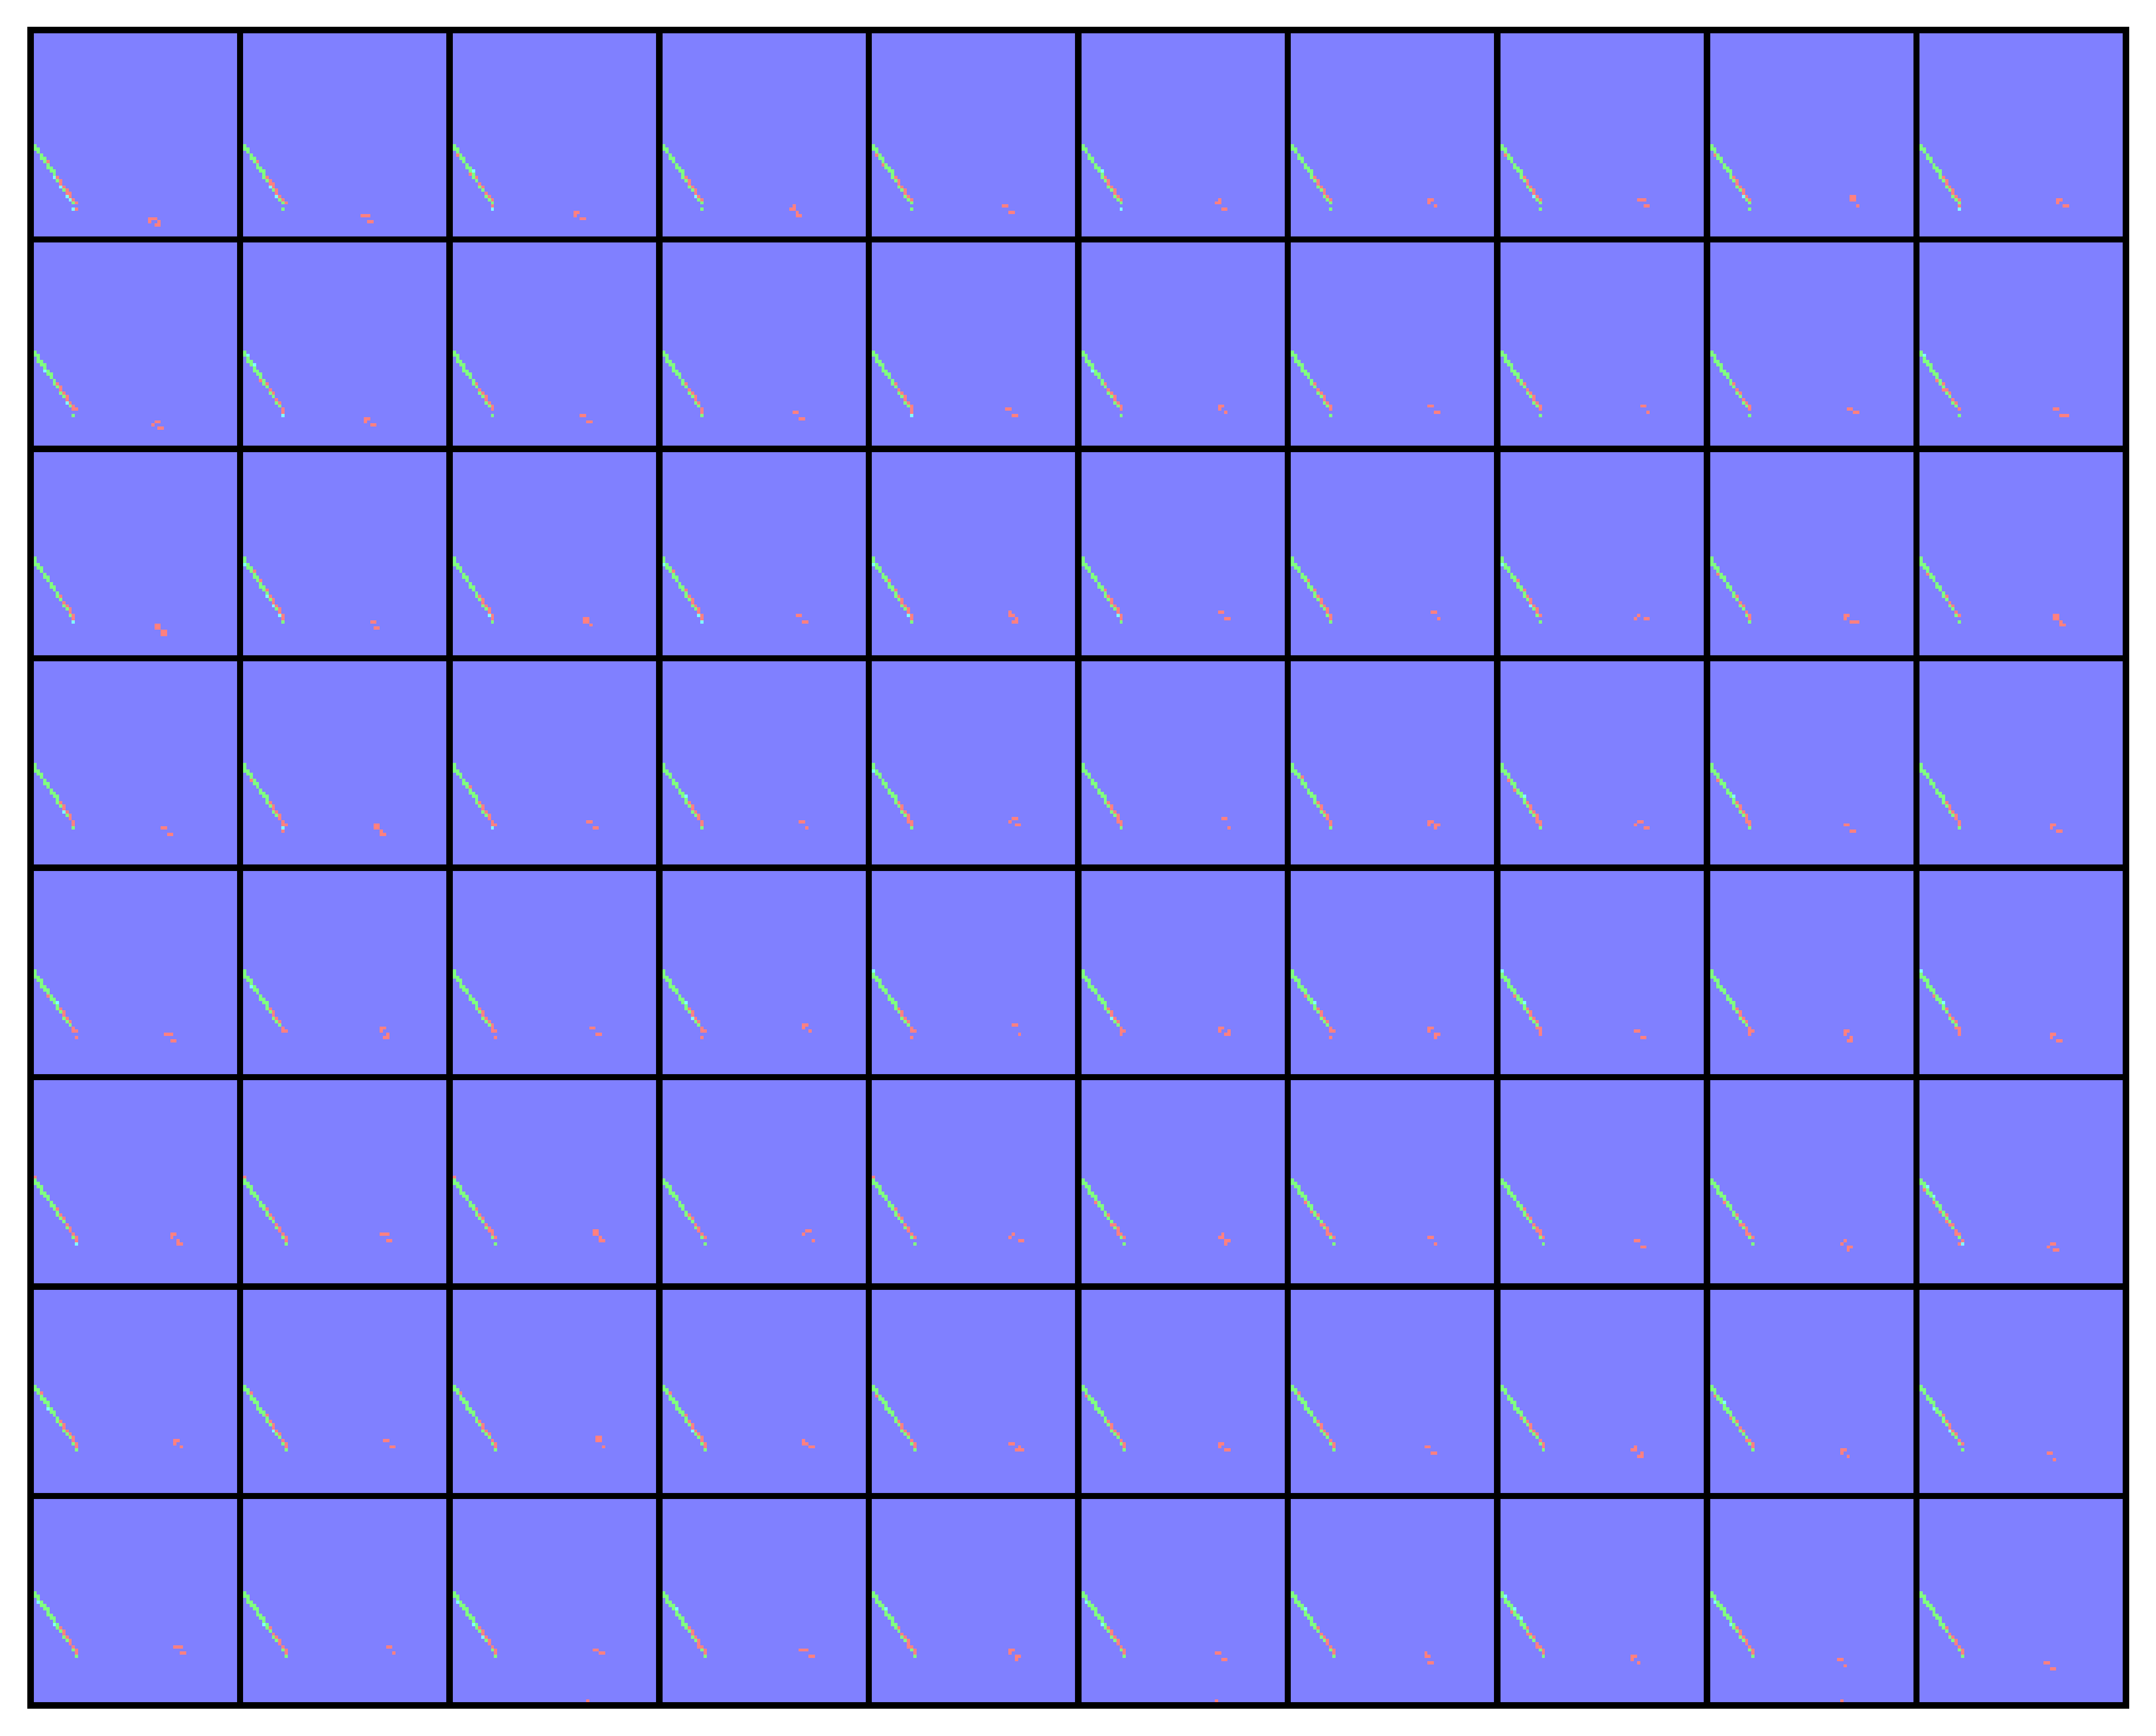

In [49]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

test_dataset = PredOccDataset(
    data_root="/home/ewhaglab/develop/data/OGM-datasets/OGM-Turtlebot2/test/",
    split="test"
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
batch = next(iter(test_loader))

batch_out = preprocess_batch_test(batch, device=device)
x = make_video(batch_out)  # (B,T,3,H,W)

#x = torch.load("test_video.pt").to(device)
B, T, C, H, W = x.shape
print(x.shape)
x = x.view(-1, C, H, W).to(device=device)
save_image(x, "input.png", nrow=10, normalize=True, value_range=(-1, 1))
print(x.shape)

img = mpimg.imread('input.png')

plt.figure(figsize=(10, 8), dpi=500)
plt.imshow(img)
plt.axis('off') 
plt.show()

In [50]:
choice = {
    'predict': 0,
    'backward': 1,
    'interpolation': 2,
    'unconditional': 3,
    'one_frame': 4,
    'arbitrary_interpolation': 5,
    'spatial_temporal': 6
}
#choice_name = input("Please select task type: ")
choice_name = 'predict' 
choice_idx = choice[choice_name]

Reconstruction MSE: 0.011014


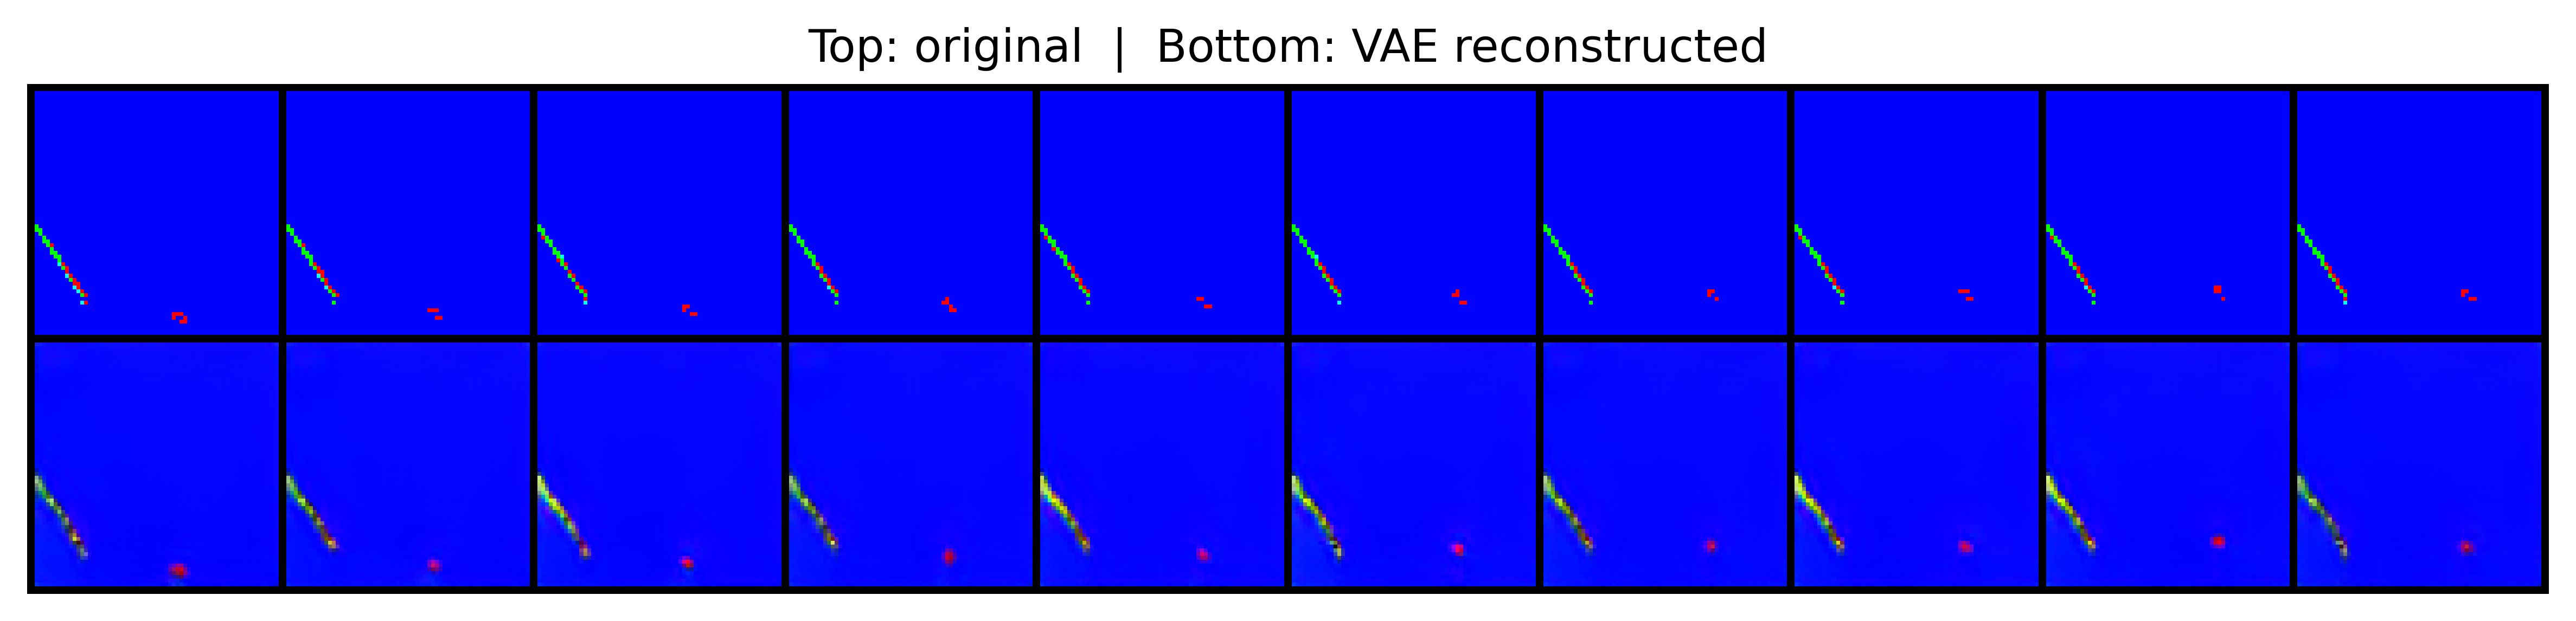

In [52]:
# VAE reconstruction test
with torch.no_grad():
    z = vae.encode(x).latent_dist.sample()
    recon = vae.decode(z).sample

# MSE reconstruction error
mse = F.mse_loss(recon, x)
print(f"Reconstruction MSE: {mse.item():.6f}")

# Visualize: original (top) vs reconstructed (bottom), first 10 frames
n_show = min(10, x.shape[0])
comparison = torch.cat([x[:n_show], recon[:n_show]], dim=0)  # (2*n_show, C, H, W)
save_image(comparison, "vae_recon_test.png", nrow=n_show, normalize=False, value_range=(0, 1))

img = mpimg.imread("vae_recon_test.png")
plt.figure(figsize=(12, 4), dpi=500)
plt.imshow(img)
plt.title("Top: original  |  Bottom: VAE reconstructed")
plt.axis("off")
plt.show()

In [53]:
print(x.shape)
raw_x = x
with torch.no_grad():
    # Map input images to latent space + normalize latents:
    x = vae.encode(x).latent_dist.sample().mul_(0.18215)
x = x.view(-1, args.num_frames, 4, x.shape[-2], x.shape[-1])
print(x.shape)
print(latent_size)
z = torch.randn(B, args.num_frames, 4, latent_size, latent_size, device=device)

generator = VideoMaskGenerator((x.shape[-4], x.shape[-2], x.shape[-1]))
mask = generator(B, device, idx=choice_idx)
print(mask.shape)
sample_fn = model.forward

# Sample images:
#(B,T,C,H,W)
z = z.permute(0, 2, 1, 3, 4)
samples = diffusion.p_sample_loop(
    sample_fn, z.shape, z, clip_denoised=False, progress=True, device=device,
    raw_x=x, mask=mask
)

# abc->acb->bac
# samples = samples.permute(0, 2, 1, 3, 4)
#(B,T,C,H,W)
samples = samples.permute(1, 0, 2, 3, 4) * mask + x.permute(2, 0, 1, 3, 4) * (1-mask)

samples = samples.permute(1, 2, 0, 3, 4) # 4, 16, 8, 32, 32 -> 16 8 4
samples = samples.reshape(-1, 4, latent_size, latent_size) / 0.18215


decoded_chunks = []
chunk_size = 256

num_chunks = (samples.shape[0] + chunk_size - 1) // chunk_size
for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, samples.shape[0])
    chunk = samples[start_idx:end_idx]
    
    decoded_chunk = vae.decode(chunk).sample
    decoded_chunks.append(decoded_chunk)


samples = torch.cat(decoded_chunks, dim=0)


samples = samples.reshape(-1, args.num_frames, samples.shape[-3], samples.shape[-2], samples.shape[-1])

mask = F.interpolate(mask.float(), size=(raw_x.shape[-2], raw_x.shape[-1]), mode='nearest')
mask = mask.unsqueeze(0).repeat(3,1,1,1,1).permute(1, 2, 0, 3, 4) 

raw_x = raw_x.reshape(-1, args.num_frames, raw_x.shape[-3], raw_x.shape[-2], raw_x.shape[-1])
raw_x = raw_x * (1 - mask)

torch.Size([80, 3, 64, 64])
torch.Size([8, 10, 4, 8, 8])
8
torch.Size([8, 10, 8, 8])


  0%|          | 0/16 [00:00<?, ?it/s]

torch.Size([8, 20, 3, 64, 64])


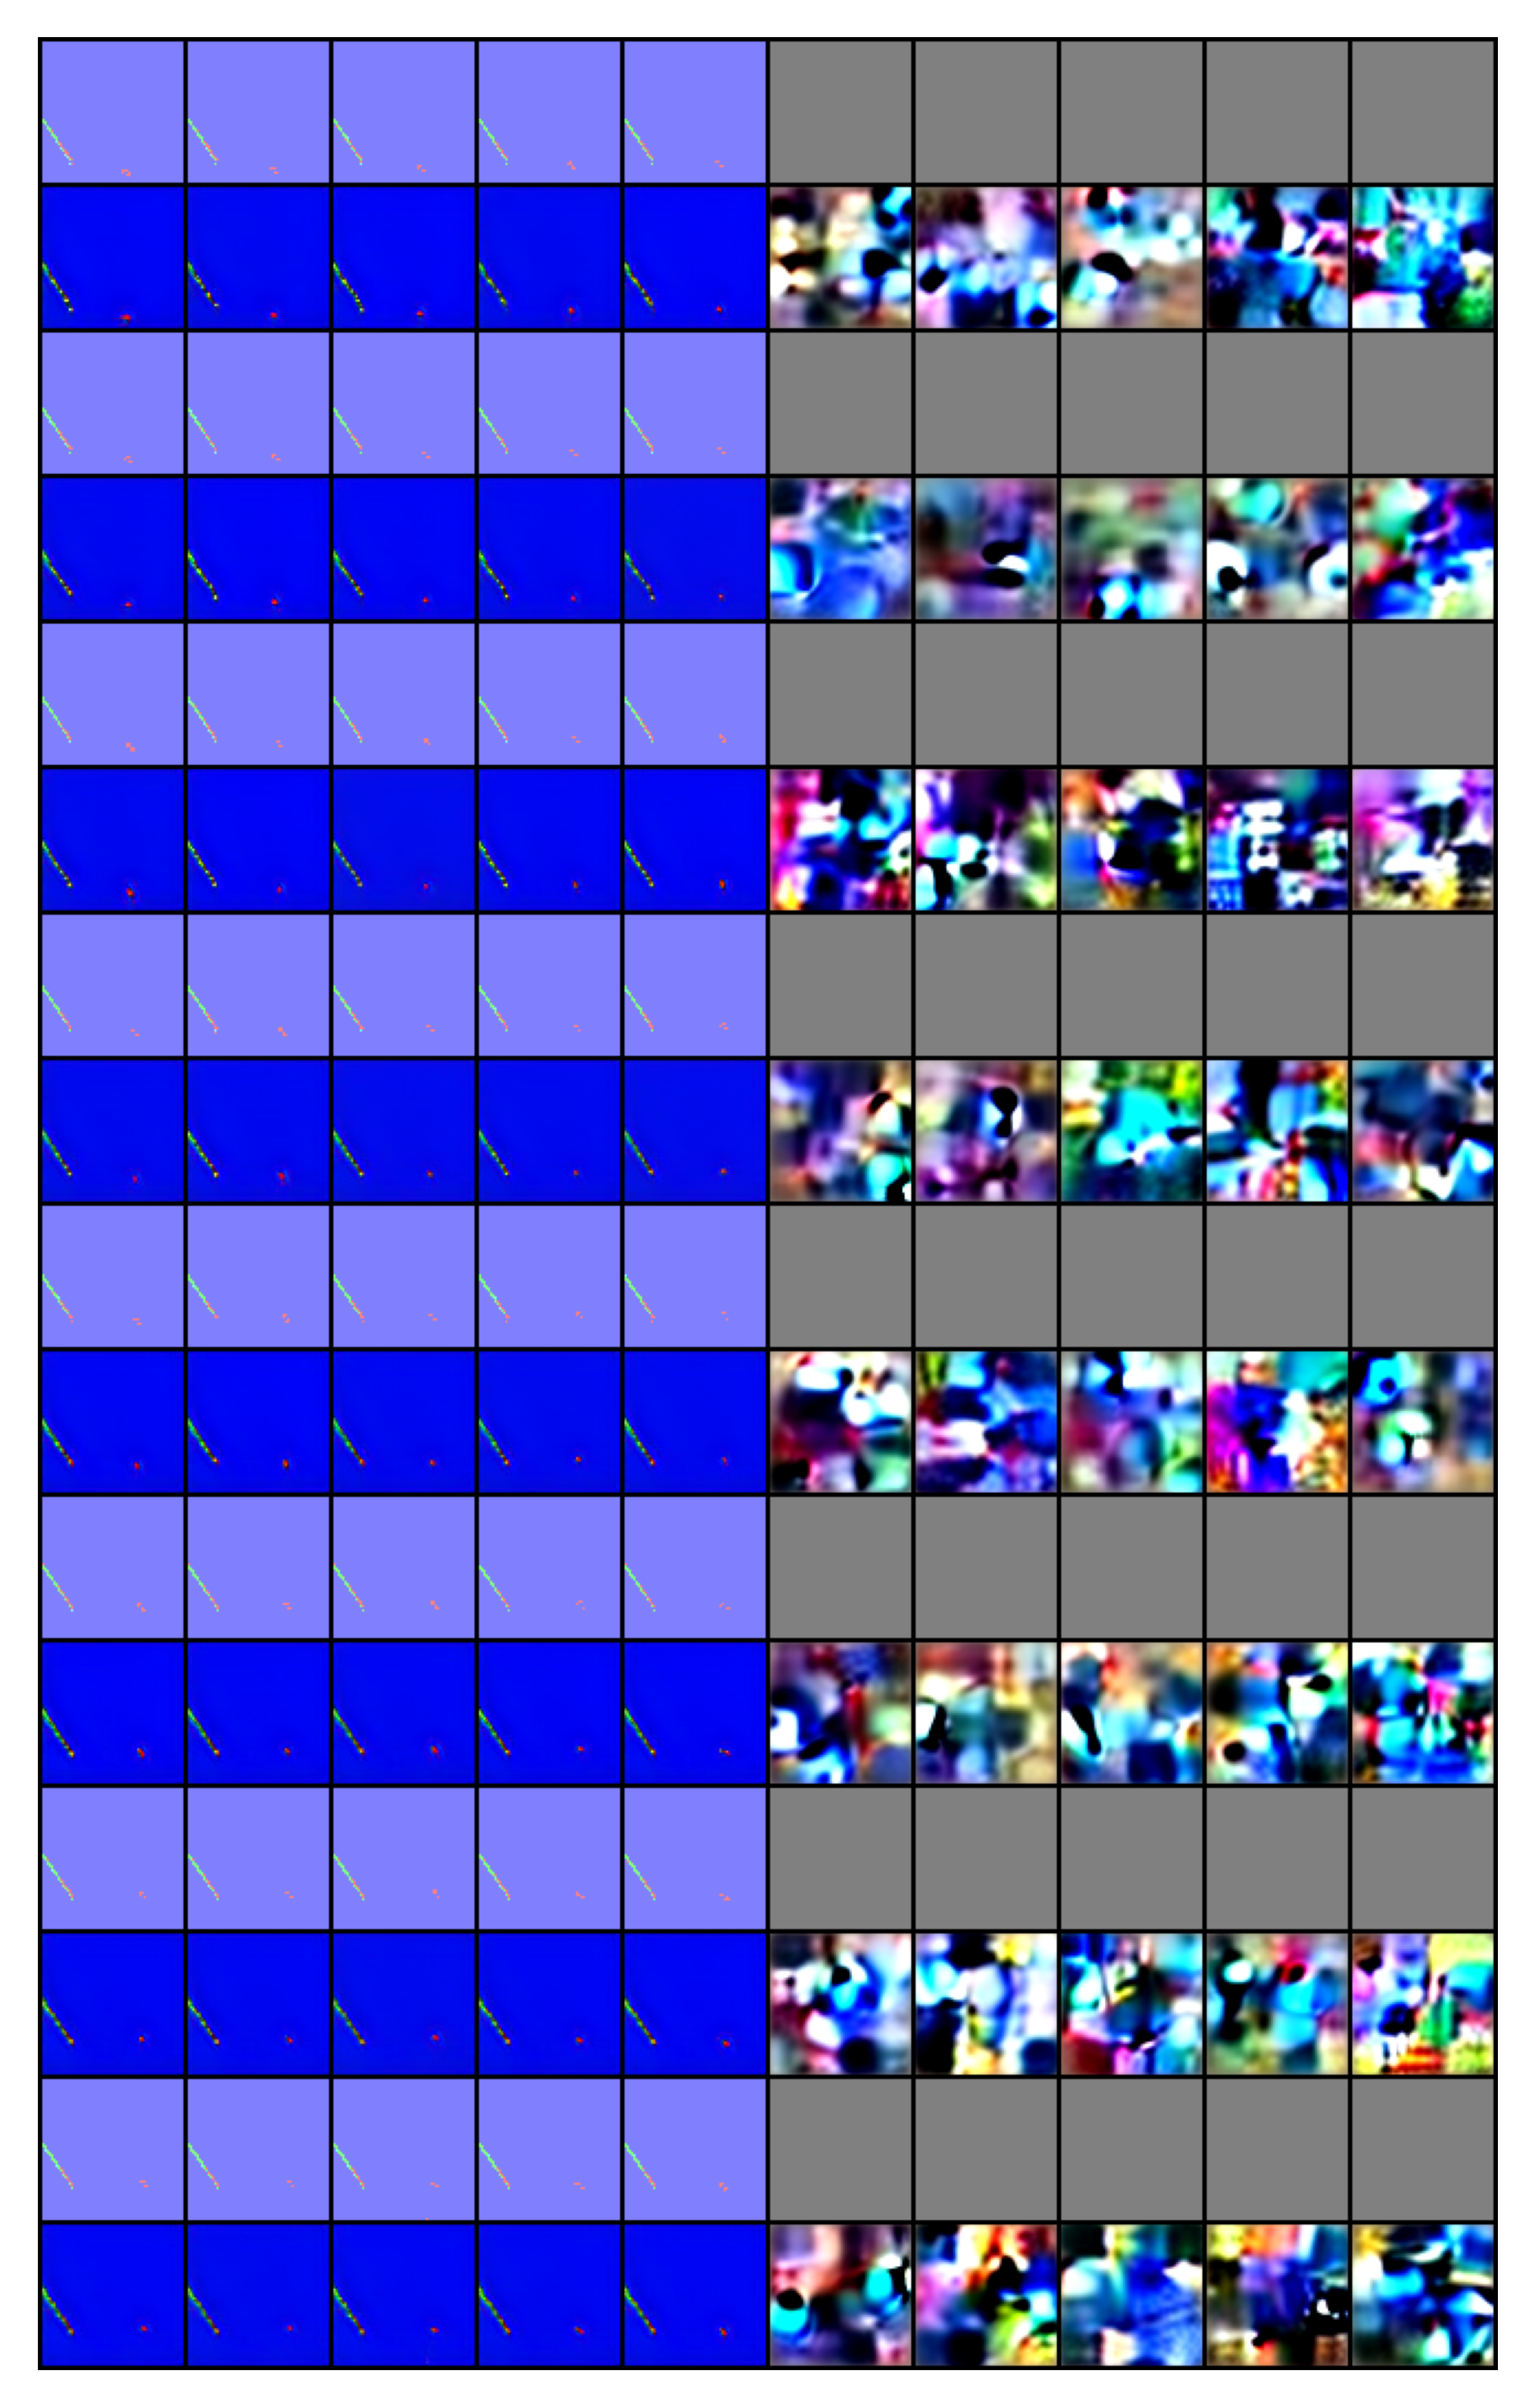

In [47]:
samples = torch.cat([raw_x, samples], dim=1)
print(samples.shape)
save_image(samples.reshape(-1, samples.shape[-3], samples.shape[-2], samples.shape[-1]), "output.png", nrow=10, normalize=True, value_range=(-1, 1))

img = mpimg.imread('output.png')

plt.figure(figsize=(10, 8), dpi=500)
plt.imshow(img)
plt.axis('off') 
plt.show()